In [2]:
import numpy as np
from sklearn.datasets import make_blobs

In [ ]:
class KMeans():
    def __init__(self, k, max_iteration=10):
        self.k = k
        self.max_it = max_iteration
        self.all_centroids = []
        self.all_labels = []

    def get_labels(self, dataset, centroids):
        labels = []
        for x in dataset:
            distances = np.sum((x - centroids)**2, axis=1)
            label = np.argmin(distances)
            labels.append(label)

        return labels
    
    def get_centroids(self, dataset, labels, k):
        centroids = []

        for i in np.arange(k):
            idx_i = np.where(np.array(labels) == i)[0]
            centroid_i = dataset[idx_i, :].mean(axis=0)
            centroids.append(centroid_i)

        return centroids

    def fit(self, dataset):
        num_feature = dataset.shape[1]
        centroids = np.random.rand(self.k, num_feature)

        self.all_centroids.append(centroids)
        self.all_labels.append(None)

        iterations = 0
        old_centroids = None

        while (iterations < self.max_it) and (old_centroids is None or not np.allclose(old_centroids, centroids)):
            old_centroids = centroids
            iterations += 1

            labels = self.get_labels(dataset, centroids)
            self.all_labels.append(labels)

            centroids = self.get_centroids(dataset, labels, self.k)
            self.all_centroids.append(centroids)
        
        return centroids

In [4]:
dataset, _ = make_blobs(n_samples=250, cluster_std=3.0, random_state=36)

kmean = KMeans(k=2, max_iteration=8)
centroids = kmean.fit(dataset)

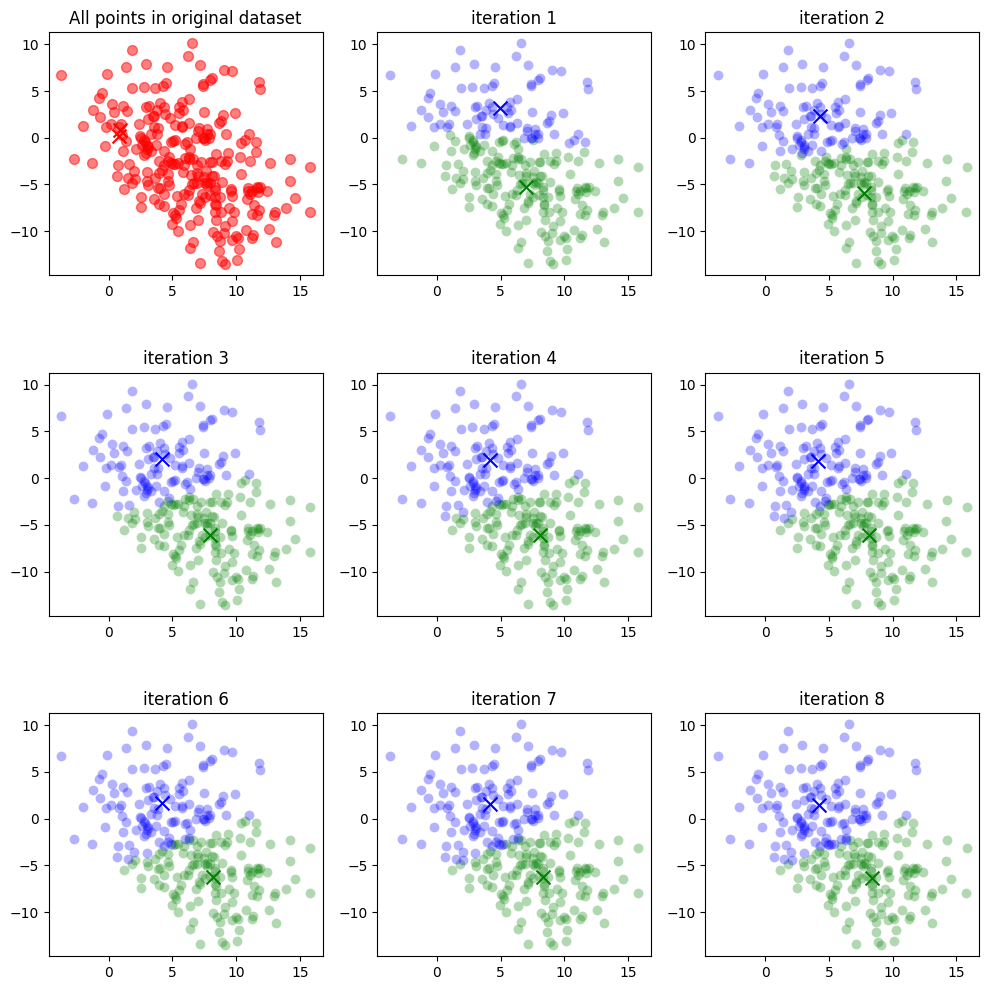

In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

gs = GridSpec(nrows=3, ncols=3)
plt.figure(figsize = (12, 12))
plt.subplots_adjust(wspace=0.2,hspace=0.4)
colors = ['green', 'blue']
labels = ['cluster 1', 'cluster 2']

for i in np.arange(len(kmean.all_centroids)):
  ax = plt.subplot(gs[i])
  if i == 0:
    centroids_i = kmean.all_centroids[i]
    plt.scatter(dataset[:, 0], dataset[:, 1], s=50, alpha=0.5, color='red')
    for j in np.arange(kmean.k):
      plt.scatter(centroids_i[j, 0], centroids_i[j, 1], marker='x', s=100, color='red')
    plt.title('All points in original dataset')
  else:
    # Lấy centroids và labels tại bước thứ i
    centroids_i = np.array(kmean.all_centroids[i])
    labels_i = kmean.all_labels[i]
    # Visualize các điểm cho từng cụm
    for j in np.arange(kmean.k):
      idx_j = np.where(np.array(labels_i) == j)[0]
      plt.scatter(dataset[idx_j, 0], dataset[idx_j, 1], color=colors[j], label=labels[j], s=50, alpha=0.3, lw = 0)
      plt.scatter(centroids_i[j, 0], centroids_i[j, 1], marker='x', color=colors[j], s=100, label=labels[j])
    plt.title(r'iteration {}'.format(i))

In [1]:
import pandas as pd
import numpy as np

data = {
    'Hoc sinh' : ['HS1', 'HS2', 'HS3', 'HS4', 'HS5'],
    'Toan': [80, 70, 90, 60, 75],
    'Ly': [85, 75, 95, 65, 70],
    'Hoa': [90, 80, 85, 70, 75]
}

df = pd.DataFrame(data)
df.head()

,Hoc sinh,Toan,Ly,Hoa
0,HS1,80,85,90
1,HS2,70,75,80
2,HS3,90,95,85
3,HS4,60,65,70
4,HS5,75,70,75


In [ ]:
mean = df[['Toan', 'Ly', 'Hoa']].mean()
std = df[['Toan', 'Ly', 'Hoa']].std(ddof=0)